In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact


In [2]:
!apt-get install -y fonts-nanum -q > /dev/null

import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [3]:
df=pd.read_csv('/content/FDA_adverse_events_final.csv')

In [4]:
# R계열(호흡기계)만 필터
r = df[df['WHO_ATC'] == 'R'].copy()

#분류에 쓸 키워드 사전
antih_kw = ['CETIRIZINE', 'LORATADINE', 'FEXOFENADINE', 'DESLORATADINE', 'LEVOCETIRIZINE',
            'DIPHENHYDRAMINE', 'CHLORPHENIRAMINE', 'BROMPHENIRAMINE', 'TRIPROLIDINE',
            'DOXYLAMINE', 'DIMENHYDRINATE', 'HYDROXYZINE', 'MECLIZINE',
            'ZYRTEC', 'ALLEGRA', 'CLARITIN', 'BENADRYL', 'XYZAL']
sleep_antih_kw = ['DIPHENHYDRAMINE', 'DOXYLAMINE']  # PM류 수면유도 항히스타민만
decon_kw = ['PSEUDOEPHEDRINE', 'PHENYLEPHRINE', 'OXYMETAZOLINE', 'XYLOMETAZOLINE',
            'NAPHAZOLINE', 'PHENYLPROPANOLAMINE', 'SUDAFED', 'AFRIN', 'NEO-SYNEPHRINE',
            'SINEX', 'OTRIVIN']
cough_kw = ['GUAIFENESIN', 'DEXTROMETHORPHAN', 'CODEINE', 'BENZONATATE', 'ROBITUSSIN',
            'MUCINEX', 'DELSYM', 'TESSALON']
pain_kw = ['ACETAMINOPHEN', 'PARACETAMOL', 'IBUPROFEN', 'ASPIRIN', 'NAPROXEN']
steroid_kw = ['FLUTICASONE', 'BUDESONIDE', 'BECLOMETHASONE', 'MOMETASONE', 'CICLESONIDE',
              'FLUNISOLIDE', 'TRIAMCINOLONE', 'FLOVENT', 'PULMICORT', 'QVAR', 'ASMANEX',
              'SYMBICORT', 'ADVAIR', 'BREO', 'NASACORT', 'RHINOCORT', 'FLONASE', 'NASONEX']
child_kw = ["CHILDREN'S", "CHILDRENS", 'PEDIATRIC', 'INFANT']  # 의심의약품 필드에만 적용 (브랜드 별칭 오탐 방지)
pm_kw = ['PM;', 'PM ', ' PM', 'UNISOM', 'ZZZQUIL', 'NIGHTTIME', 'NIGHT TIME', 'NIGHT-TIME']


def U(s):
    return '' if pd.isna(s) else str(s).upper()


def has_any(text, kws):
    return any(k in text for k in kws)


def classify(row):
    sd = U(row['suspect_drug'])
    bn = U(row['brand_name'])
    combo = sd + ' ' + bn

    is_child = has_any(sd, child_kw)
    has_antih = has_any(combo, antih_kw)
    has_sleep_antih = has_any(combo, sleep_antih_kw)
    has_decon = has_any(combo, decon_kw)
    has_cough = has_any(combo, cough_kw)
    has_pain = has_any(combo, pain_kw)
    has_steroid = has_any(combo, steroid_kw)
    has_pm_word = has_any(combo, pm_kw)
    is_pm = has_pm_word or (has_sleep_antih and has_pain and not has_decon)

    if has_steroid:
        return 'F. 흡입형 스테로이드'
    if is_child:
        return 'G. 소아 감기약 복합제'
    if is_pm:
        return 'D. 수면유도 복합제(PM류)'
    if has_antih and has_decon:
        return 'E. 항히스타민+비충혈제거제 복합감기약'
    if has_antih and not has_decon and not has_cough and not has_pain:
        return 'A. 항히스타민제(단일)'
    if has_decon and not has_antih and not has_cough and not has_pain:
        return 'C. 비충혈제거제(단일)'
    if has_cough and not has_antih and not has_decon:
        return 'B. 진해거담제'
    return 'H. 기타'


# 전체 R계열에 분류 적용
r['category'] = r.apply(classify, axis=1)

#  C그룹(비충혈제거제 단일)만 추출
C = r[r['category'] == 'C. 비충혈제거제(단일)'].copy()

print(f'R계열 전체: {len(r)}건')
print(f'C그룹(비충혈제거제 단일): {len(C)}건')

R계열 전체: 1562건
C그룹(비충혈제거제 단일): 115건


In [5]:
def dist_table(d, col, label):
    cnt = d[col].value_counts()
    pct = (cnt / len(d) * 100).round(1)
    return pd.DataFrame({f'{label}_건수': cnt, f'{label}_비율(%)': pct})

# 성별
sex_all = dist_table(df, 'patient_sex', '전체데이터')
sex_r = dist_table(r, 'patient_sex', 'R전체')
sex_c = dist_table(C, 'patient_sex', 'C그룹')
sex_compare = sex_all.join(sex_r, how='outer').join(sex_c, how='outer').fillna(0)

# 연령대
age_all = dist_table(df, 'age_group', '전체데이터')
age_r = dist_table(r, 'age_group', 'R전체')
age_c = dist_table(C, 'age_group', 'C그룹')
age_compare = age_all.join(age_r, how='outer').join(age_c, how='outer').fillna(0)
age_order = ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)', 'Adult(19-40)',
             'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)', 'Unknown']
age_compare = age_compare.reindex([a for a in age_order if a in age_compare.index])

# 복약수
dc_all = dist_table(df, 'drug_count_category', '전체데이터')
dc_r = dist_table(r, 'drug_count_category', 'R전체')
dc_c = dist_table(C, 'drug_count_category', 'C그룹')
dc_compare = dc_all.join(dc_r, how='outer').join(dc_c, how='outer').fillna(0)
cat_order = ['Single', '2-3 Drugs', '4-5 Drugs', 'Polypharmacy(6+)', 'Unknown']
dc_compare = dc_compare.reindex([c for c in cat_order if c in dc_compare.index])

print('=== 성별 분포 ===')
print(sex_compare)
print()
print('=== 연령대 분포 ===')
print(age_compare)
print()
print('=== 복약수 분포 ===')
print(dc_compare)

=== 성별 분포 ===
             전체데이터_건수  전체데이터_비율(%)  R전체_건수  R전체_비율(%)  C그룹_건수  C그룹_비율(%)
patient_sex                                                             
Female           9088         49.7     900       57.6      70       60.9
Male             6510         35.6     487       31.2      40       34.8
Unknown          2675         14.6     175       11.2       5        4.3

=== 연령대 분포 ===
                    전체데이터_건수  전체데이터_비율(%)  R전체_건수  R전체_비율(%)  C그룹_건수  \
age_group                                                              
Infant(0-2)              163          0.9      23        1.5     1.0   
Child(3-12)              258          1.4      56        3.6     0.0   
Teen(13-18)              308          1.7      37        2.4     2.0   
Adult(19-40)            1628          8.9     221       14.1    20.0   
Middle-Aged(41-65)      5891         32.2     363       23.2    33.0   
Senior(66-80)           3648         20.0     233       14.9    11.0   
Elderly(81+)            1116 

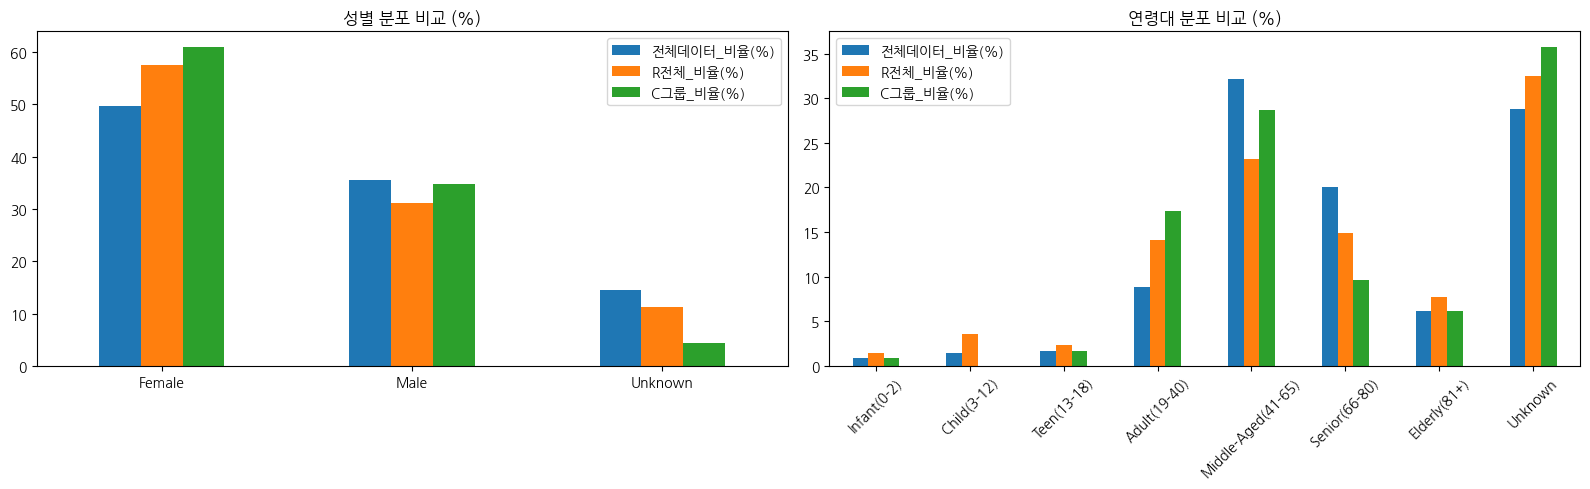

In [6]:
# 성별 / 연령대 분포 비교 그래프 (전체vsr계열vsc그룹)
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sex_compare[['전체데이터_비율(%)', 'R전체_비율(%)', 'C그룹_비율(%)']].plot(kind='bar', ax=axes[0])
axes[0].set_title('성별 분포 비교 (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

age_compare[['전체데이터_비율(%)', 'R전체_비율(%)', 'C그룹_비율(%)']].plot(kind='bar', ax=axes[1])
axes[1].set_title('연령대 분포 비교 (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

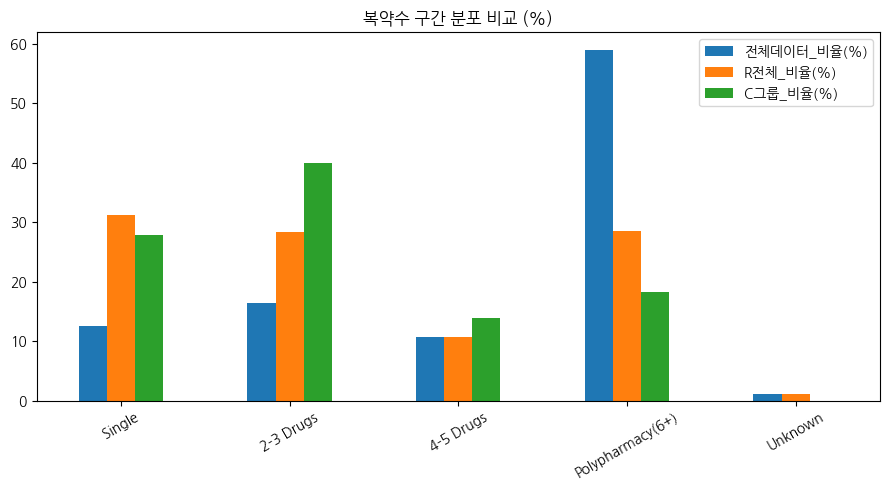

In [7]:
# 복약수 구간 분포 비교 그래프 (전체vsr계열vsc그룹)
fig, ax = plt.subplots(figsize=(9, 5))
dc_compare[['전체데이터_비율(%)', 'R전체_비율(%)', 'C그룹_비율(%)']].plot(kind='bar', ax=ax)
ax.set_title('복약수 구간 분포 비교 (%)')
ax.set_xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [8]:
sev_cols = ['serious', 'is_fatal', 'is_hospitalized', 'is_life_threat', 'is_disabling']
sev_labels = {
    'serious': 'Serious(전체)',
    'is_fatal': '사망',
    'is_hospitalized': '입원',
    'is_life_threat': '생명위협',
    'is_disabling': '장애'
}

def sev_rate(df_group, col):
    v = df_group[col].astype(str)
    pos = 'Yes' if col == 'serious' else 'True'
    return round((v == pos).mean() * 100, 1)

sev_compare_all = pd.DataFrame({
    '전체데이터_비율(%)': [sev_rate(df, c) for c in sev_cols],
    'R전체_비율(%)': [sev_rate(r, c) for c in sev_cols],
    'C그룹_비율(%)': [sev_rate(C, c) for c in sev_cols],
}, index=[sev_labels[c] for c in sev_cols])

print('=== 심각도 지표 비교 (전체데이터 vs R전체 vs C그룹) ===')
print(sev_compare_all)

=== 심각도 지표 비교 (전체데이터 vs R전체 vs C그룹) ===
             전체데이터_비율(%)  R전체_비율(%)  C그룹_비율(%)
Serious(전체)         85.6       55.1       49.6
사망                  14.4        7.0        1.7
입원                  34.4       19.9       16.5
생명위협                 5.5        4.2       10.4
장애                   3.1        3.2        0.9


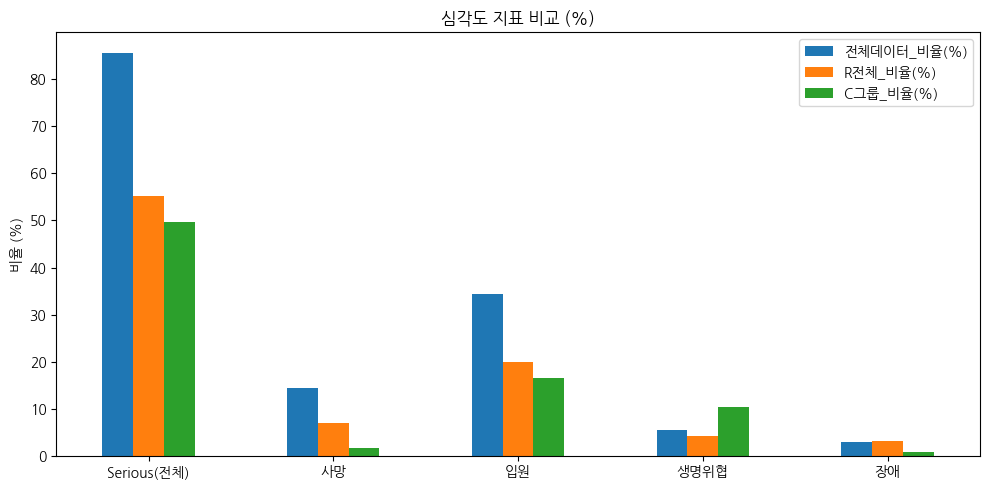

In [9]:
# 심각도 지표 비교 그래프 (전체vsr계열vsc그룹)
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 5))
sev_compare_all.plot(kind='bar', ax=ax)
ax.set_title('심각도 지표 비교 (%)')
ax.set_xlabel('')
ax.set_ylabel('비율 (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
cardio_kw = ['Hypertension', 'Tachycardia', 'Palpitation', 'Arrhythmia', 'Chest pain', 'Hypertensive']

def cardio_rate(d):
    mask = d['reactions'].astype(str).str.contains('|'.join(cardio_kw), case=False, na=False)
    return mask.sum(), round(mask.mean() * 100, 1)

c_n, c_pct = cardio_rate(C)
r_n, r_pct = cardio_rate(r)
all_n, all_pct = cardio_rate(df)

print('=== 심혈관계 관련 반응 포함 비율 (Hypertension/Tachycardia/Palpitation 등) ===')
print(f'C그룹     : {c_n}/{len(C)}건 = {c_pct}%')
print(f'R전체     : {r_n}/{len(r)}건 = {r_pct}%')
print(f'전체데이터 : {all_n}/{len(df)}건 = {all_pct}%')

=== 심혈관계 관련 반응 포함 비율 (Hypertension/Tachycardia/Palpitation 등) ===
C그룹     : 11/115건 = 9.6%
R전체     : 80/1562건 = 5.1%
전체데이터 : 583/18273건 = 3.2%


In [11]:
reaction_counts = C['primary_reaction'].value_counts()
reaction_pct = (reaction_counts / len(C) * 100).round(1)

reaction_table = pd.DataFrame({
    '건수': reaction_counts,
    '비율(%)': reaction_pct
})

print('=== C그룹 내 대표 부작용 Top 15 ===')
print(reaction_table.head(15))
print()
print(f"고유 반응 종류: {C['primary_reaction'].nunique()}종 / 전체 {len(C)}건")

once = (reaction_counts == 1).sum()
print(f"1건만 보고된 반응: {once}종 ({once/C['primary_reaction'].nunique()*100:.0f}%)")

=== C그룹 내 대표 부작용 Top 15 ===
                                          건수  비율(%)
primary_reaction                                   
Drug ineffective                          11    9.6
Off label use                              6    5.2
Drug dependence                            6    5.2
Wrong technique in product usage process   3    2.6
Drug screen positive                       3    2.6
Therapeutic response unexpected            3    2.6
Nausea                                     3    2.6
Extra dose administered                    2    1.7
Arthralgia                                 2    1.7
Hypertensive emergency                     2    1.7
Palpitations                               2    1.7
Drug hypersensitivity                      2    1.7
Pruritus                                   2    1.7
Somnolence                                 2    1.7
Intentional product misuse                 2    1.7

고유 반응 종류: 72종 / 전체 115건
1건만 보고된 반응: 50종 (69%)


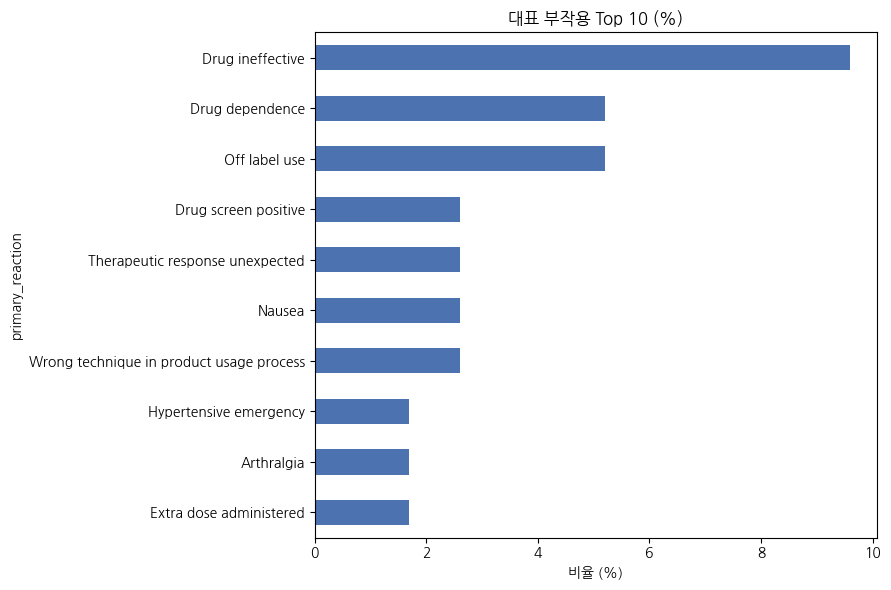

In [12]:
# 대표부작용 그래프
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(9, 6))
reaction_table.head(10)['비율(%)'].sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('대표 부작용 Top 10 (%)')
ax.set_xlabel('비율 (%)')
plt.tight_layout()
plt.show()

In [13]:
reaction_group_map = {
    # 오남용/사용행태
    'Off label use':'오남용/사용행태','Drug dependence':'오남용/사용행태',
    'Wrong technique in product usage process':'오남용/사용행태','Drug screen positive':'오남용/사용행태',
    'Extra dose administered':'오남용/사용행태','Intentional product misuse':'오남용/사용행태',
    'Incorrect dose administered':'오남용/사용행태','Drug ineffective for unapproved indication':'오남용/사용행태',
    'Incorrect product administration duration':'오남용/사용행태','Inappropriate schedule of product administration':'오남용/사용행태',
    'Amphetamines positive':'오남용/사용행태','Product administered to patient of inappropriate age':'오남용/사용행태',
    'Unintentional use for unapproved indication':'오남용/사용행태','Product use in unapproved indication':'오남용/사용행태',
    'Product use complaint':'오남용/사용행태','Product label issue':'오남용/사용행태',
    'Incorrect drug administration duration':'오남용/사용행태','Expired product administered':'오남용/사용행태',
    'Product package associated injury':'오남용/사용행태',
    # 치료효과 미흡
    'Drug ineffective':'치료효과 미흡','Therapeutic response unexpected':'치료효과 미흡',
    'Therapeutic response decreased':'치료효과 미흡','Drug level increased':'치료효과 미흡',
    'Condition aggravated':'치료효과 미흡',
    # 심혈관계
    'Palpitations':'심혈관계','Hypertensive emergency':'심혈관계','Vasospasm':'심혈관계',
    'Myocardial infarction':'심혈관계','Hypertension':'심혈관계','Sinus node dysfunction':'심혈관계',
    'Extrasystoles':'심혈관계','Flushing':'심혈관계','Bradycardia':'심혈관계',
    'Anterior spinal artery syndrome':'심혈관계','Electrocardiogram QT prolonged':'심혈관계',
    'Stress cardiomyopathy':'심혈관계','Haemorrhage intracranial':'심혈관계',
    # 신경/정신계
    'Somnolence':'신경/정신계','Mania':'신경/정신계','Aphasia':'신경/정신계','Visual impairment':'신경/정신계',
    'Headache':'신경/정신계','Vertigo':'신경/정신계','Stupor':'신경/정신계','Agitation':'신경/정신계',
    'Anxiety':'신경/정신계','Cognitive disorder':'신경/정신계','Hallucination':'신경/정신계',
    'Depressed level of consciousness':'신경/정신계','Ageusia':'신경/정신계','Facial paresis':'신경/정신계',
    'Tremor':'신경/정신계',
    # 알레르기/피부
    'Pruritus':'알레르기/피부','Hypersensitivity':'알레르기/피부','Drug hypersensitivity':'알레르기/피부',
    'Rash pruritic':'알레르기/피부','Eosinophilic granulomatosis with polyangiitis':'알레르기/피부',
    # 위장관계
    'Nausea':'위장관계','Mouth ulceration':'위장관계','Diarrhoea':'위장관계','Dry mouth':'위장관계',
    'Necrotising colitis':'위장관계',
    # 근골격/비뇨기
    'Arthralgia':'근골격/비뇨기','Arthropathy':'근골격/비뇨기','Urinary hesitation':'근골격/비뇨기',
    'Dysuria':'근골격/비뇨기',
    # 기타
    'Malaise':'기타','Sinusitis':'기타','Dyspnoea':'기타',
    'Maternal exposure during pregnancy':'기타','Normal newborn':'기타','Blood glucose decreased':'기타',
}

C['reaction_group'] = C['primary_reaction'].map(reaction_group_map).fillna('기타')

group_counts = C['reaction_group'].value_counts()
group_pct = (group_counts / len(C) * 100).round(1)
reaction_group_table = pd.DataFrame({'건수': group_counts, '비율(%)': group_pct})

print('=== C그룹 부작용 카테고리별 분포 ===')
print(reaction_group_table)
print('합계:', group_counts.sum(), '/', len(C))

=== C그룹 부작용 카테고리별 분포 ===
                건수  비율(%)
reaction_group           
오남용/사용행태        39   33.9
치료효과 미흡         18   15.7
신경/정신계          17   14.8
심혈관계            15   13.0
알레르기/피부          8    7.0
위장관계             7    6.1
기타               6    5.2
근골격/비뇨기          5    4.3
합계: 115 / 115


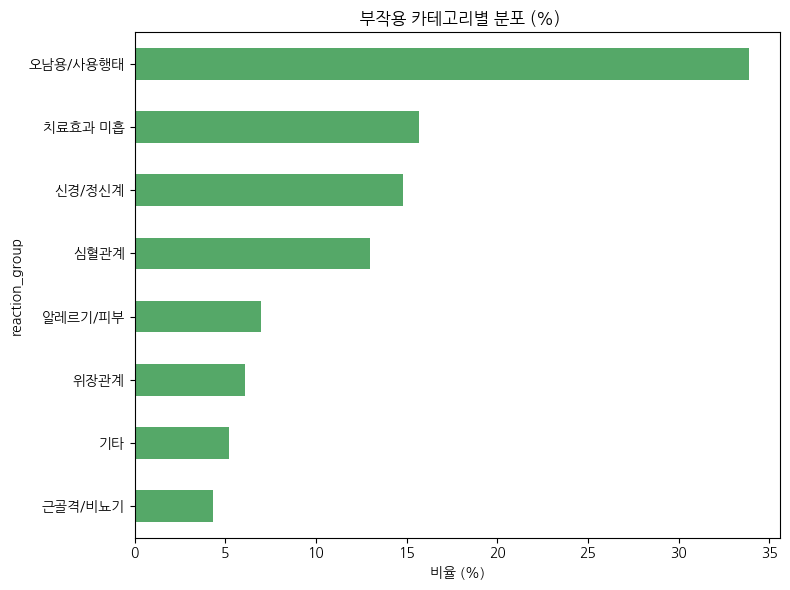

In [14]:
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(8, 6))
reaction_group_table['비율(%)'].sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_title(' 부작용 카테고리별 분포 (%)')
ax.set_xlabel('비율 (%)')
plt.tight_layout()
plt.show()

In [15]:
def classify_reaction(reaction):
    t = str(reaction).upper()
    if any(k in t for k in ['MISUSE','DEPENDENCE','OFF LABEL','OFF-LABEL','INCORRECT DOSE','INCORRECT PRODUCT',
                             'WRONG TECHNIQUE','UNAPPROVED','INAPPROPRIATE','EXPIRED PRODUCT','EXTRA DOSE',
                             'OVERDOSE','INTENTIONAL','SCREEN POSITIVE','AMPHETAMINE','PRODUCT LABEL',
                             'PRODUCT USE','PRODUCT PACKAGE','SELF MEDICATION','SELF-MEDICATION',
                             'INCORRECT DRUG ADMINISTRATION','INAPPROPRIATE AGE']):
        return '오남용/사용행태'
    if any(k in t for k in ['INEFFECTIVE','THERAPEUTIC RESPONSE','CONDITION AGGRAVATED','LACK OF EFFICACY','DRUG LEVEL']):
        return '치료효과 미흡'
    if any(k in t for k in ['HYPERTENS','HYPOTENS','TACHYCARDIA','BRADYCARDIA','PALPITAT','ARRHYTHMIA',
                             'MYOCARDIAL','CARDIAC','CARDIOMYOPATHY','QT ','EXTRASYSTOLE','FLUSHING',
                             'VASOSPASM','ANGINA','INFARCTION']):
        return '심혈관계'
    if any(k in t for k in ['SOMNOLEN','HALLUCINAT','ANXIETY','AGITATION','HEADACHE','VERTIGO','STUPOR',
                             'DIZZINESS','COGNITIVE','MANIA','APHASIA','TREMOR','SEIZURE','CONVULS',
                             'PARESIS','CONSCIOUSNESS','DEPRESS','INSOMNIA','CONFUS']):
        return '신경/정신계'
    if any(k in t for k in ['RASH','PRURITUS','HYPERSENSITIVITY','URTICARIA','ANAPHYLA','ANGIOEDEMA',
                             'ALLERGIC','ALLERGY','ERYTHEMA','DERMATITIS','EOSINOPHILIC']):
        return '알레르기/피부'
    if any(k in t for k in ['NAUSEA','VOMIT','DIARRHOEA','DIARRHEA','CONSTIPATION','ABDOMINAL','GASTR',
                             'MOUTH ULCER','DRY MOUTH','COLITIS']):
        return '위장관계'
    if any(k in t for k in ['ARTHRALGIA','ARTHROPATHY','MYALGIA','MUSCLE','URINARY','DYSURIA','RENAL','KIDNEY']):
        return '근골격/비뇨기'
    return '미분류/기타'

C['reaction_group_kw'] = C['primary_reaction'].apply(classify_reaction)
r['reaction_group_kw'] = r['primary_reaction'].apply(classify_reaction)
df['reaction_group_kw'] = df['primary_reaction'].apply(classify_reaction)

cats_order = ['오남용/사용행태','치료효과 미흡','심혈관계','신경/정신계','알레르기/피부','위장관계','근골격/비뇨기']

def pct_table_excl(d):
    d2 = d[d['reaction_group_kw'] != '미분류/기타']
    cnt = d2['reaction_group_kw'].value_counts()
    pct = (cnt / len(d2) * 100).round(1)
    return pct.reindex(cats_order).fillna(0), len(d2)

c_pct, c_n = pct_table_excl(C)
r_pct, r_n = pct_table_excl(r)
all_pct, all_n = pct_table_excl(df)

reaction_group_compare_excl = pd.DataFrame({
    'C그룹(%)': c_pct,
    'R전체(%)': r_pct,
    '전체데이터(%)': all_pct,
})

print('=== 부작용 카테고리 비교 (미분류/기타 제외) ===')
print(reaction_group_compare_excl)
print()
print(f'분류된 건수: C그룹 {c_n}/{len(C)}, R전체 {r_n}/{len(r)}, 전체데이터 {all_n}/{len(df)}')

=== 부작용 카테고리 비교 (미분류/기타 제외) ===
                   C그룹(%)  R전체(%)  전체데이터(%)
reaction_group_kw                          
오남용/사용행태             37.5    24.6      10.6
치료효과 미흡              17.3    20.5       5.7
심혈관계                 11.5     6.9       3.9
신경/정신계               14.4    17.6       3.8
알레르기/피부               7.7    14.1       6.5
위장관계                  6.7    12.7      13.9
근골격/비뇨기               4.8     3.6      55.5

분류된 건수: C그룹 104/115, R전체 780/1562, 전체데이터 10772/18273


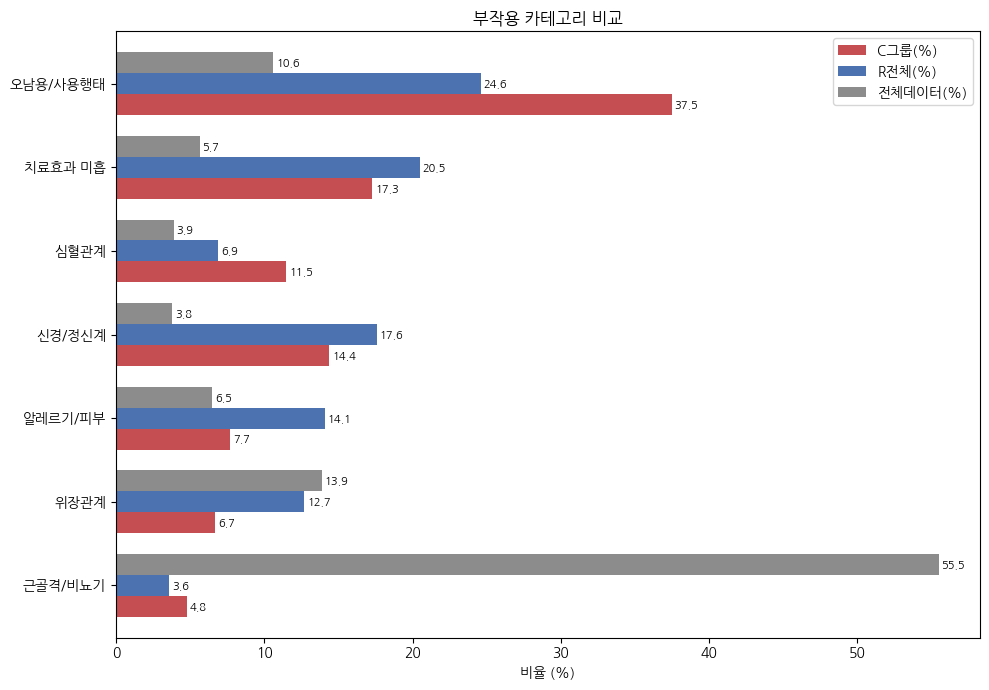

In [16]:
# 부작용 카테고리별 비교 그래프
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 7))
reaction_group_compare_excl.iloc[::-1].plot(kind='barh', ax=ax, color=['#C44E52','#4C72B0','#8C8C8C'], width=0.75)
ax.set_title('부작용 카테고리 비교')
ax.set_xlabel('비율 (%)')
ax.set_ylabel('')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

In [17]:
def ingredient(row):
    t = (str(row['suspect_drug']).upper() + ' ' + str(row['brand_name']).upper())
    if 'PSEUDOEPHEDRINE' in t or 'SUDAFED' in t:
        return 'Pseudoephedrine'
    if 'PHENYLEPHRINE' in t or 'NEO-SYNEPHRINE' in t:
        return 'Phenylephrine'
    if 'OXYMETAZOLINE' in t or 'AFRIN' in t:
        return 'Oxymetazoline'
    return 'Other'

C['ingredient'] = C.apply(ingredient, axis=1)

cardio_kw = ['Hypertension','Hypertensive','Tachycardia','Palpitation','Arrhythmia','Chest pain',
             'Myocardial','Bradycardia','Extrasystole','Cardiomyopathy','Vasospasm','Flushing',
             'Sinus node dysfunction','QT prolonged']

def has_cardio(reactions_text):
    return any(k.lower() in str(reactions_text).lower() for k in cardio_kw)

C['has_cardio'] = C['reactions'].apply(has_cardio)

cardio_summary = C.groupby('ingredient').agg(n=('has_cardio','size'), cardio_n=('has_cardio','sum'))
cardio_summary['cardio_pct'] = (cardio_summary['cardio_n'] / cardio_summary['n'] * 100).round(1)
print(cardio_summary.sort_values('cardio_pct', ascending=False))

                  n  cardio_n  cardio_pct
ingredient                               
Phenylephrine    11         7        63.6
Pseudoephedrine  94        13        13.8
Oxymetazoline     9         0         0.0
Other             1         0         0.0


In [18]:
# 적응증 confound 보정: 주사/임상용도 케이스 제외
non_otc_indications = ['Priapism', 'Hypotension', 'Prophylaxis', 'Ophthalmological Examination']
C['is_otc_use'] = ~C['drug_indication'].isin(non_otc_indications)

otc = C[C['is_otc_use']].copy()
print(f"OTC 자가복용 케이스만: {len(otc)}건 / 전체 {len(C)}건 ({len(otc)/len(C)*100:.1f}%)")

cardio_summary_otc = otc.groupby('ingredient').agg(n=('has_cardio','size'), cardio_n=('has_cardio','sum'))
cardio_summary_otc['cardio_pct'] = (cardio_summary_otc['cardio_n']/cardio_summary_otc['n']*100).round(1)
print(cardio_summary_otc.sort_values('cardio_pct', ascending=False))

pseudo = otc[otc['ingredient']=='Pseudoephedrine']
phen = otc[otc['ingredient']=='Phenylephrine']
tab = [[pseudo['has_cardio'].sum(), (~pseudo['has_cardio']).sum()],
       [phen['has_cardio'].sum(), (~phen['has_cardio']).sum()]]
odds, p = fisher_exact(tab)
print(f'\nFisher exact (Pseudoephedrine vs Phenylephrine, OTC only): odds={odds:.2f}, p={p:.4f}')

OTC 자가복용 케이스만: 105건 / 전체 115건 (91.3%)
                  n  cardio_n  cardio_pct
ingredient                               
Phenylephrine     4         2        50.0
Pseudoephedrine  91        12        13.2
Oxymetazoline     9         0         0.0
Other             1         0         0.0

Fisher exact (Pseudoephedrine vs Phenylephrine, OTC only): odds=0.15, p=0.1022


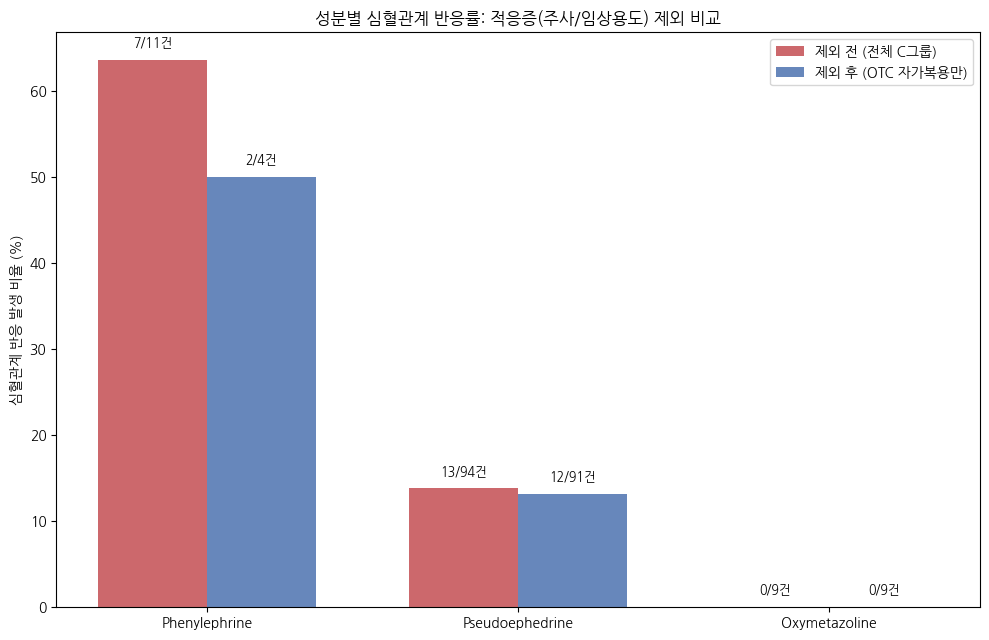

In [19]:
plt.rcParams['axes.unicode_minus'] = False
ingredients_order = ['Phenylephrine', 'Pseudoephedrine', 'Oxymetazoline']

before = cardio_summary.reindex(ingredients_order)  # 이전 셀에서 만든 전체 C그룹 기준 요약
after = cardio_summary_otc.reindex(ingredients_order)  # OTC만 필터링한 요약

x = np.arange(len(ingredients_order))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6.5))
b1 = ax.bar(x - width/2, before['cardio_pct'], width, label='제외 전 (전체 C그룹)', color='#C44E52', alpha=0.85)
b2 = ax.bar(x + width/2, after['cardio_pct'], width, label='제외 후 (OTC 자가복용만)', color='#4C72B0', alpha=0.85)

for bar, row in zip(b1, before.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5, f'{row.cardio_n}/{row.n}건', ha='center', fontsize=9)
for bar, row in zip(b2, after.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5, f'{row.cardio_n}/{row.n}건', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(ingredients_order)
ax.set_ylabel('심혈관계 반응 발생 비율 (%)')
ax.set_title('성분별 심혈관계 반응률: 적응증(주사/임상용도) 제외 비교')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
def classify_cardio(reaction):
    t = str(reaction).upper()
    if any(k in t for k in ['HYPERTENS','HYPOTENS','TACHYCARDIA','BRADYCARDIA','PALPITAT','ARRHYTHMIA',
                             'MYOCARDIAL','CARDIAC','CARDIOMYOPATHY','QT ','EXTRASYSTOLE','FLUSHING',
                             'VASOSPASM','ANGINA','INFARCTION']):
        return '심혈관계'
    return '기타'
C['is_cardio_cat'] = C['primary_reaction'].apply(classify_cardio)

tab_lt = pd.crosstab(C['is_life_threat'].astype(str), C['is_cardio_cat'])
chi2, p, dof, exp = chi2_contingency(tab_lt)
print(tab_lt)
print(f'chi2={chi2:.2f}, p={p:.4f}')

lt = C[C['is_life_threat'].astype(str) == 'True']
print(f"생명위협 케이스 {len(lt)}건 중 심혈관계가 주반응: {(lt['is_cardio_cat']=='심혈관계').sum()}건 ({(lt['is_cardio_cat']=='심혈관계').mean()*100:.1f}%)")

is_cardio_cat   기타  심혈관계
is_life_threat          
False           97     6
True             6     6
chi2=17.96, p=0.0000
생명위협 케이스 12건 중 심혈관계가 주반응: 6건 (50.0%)


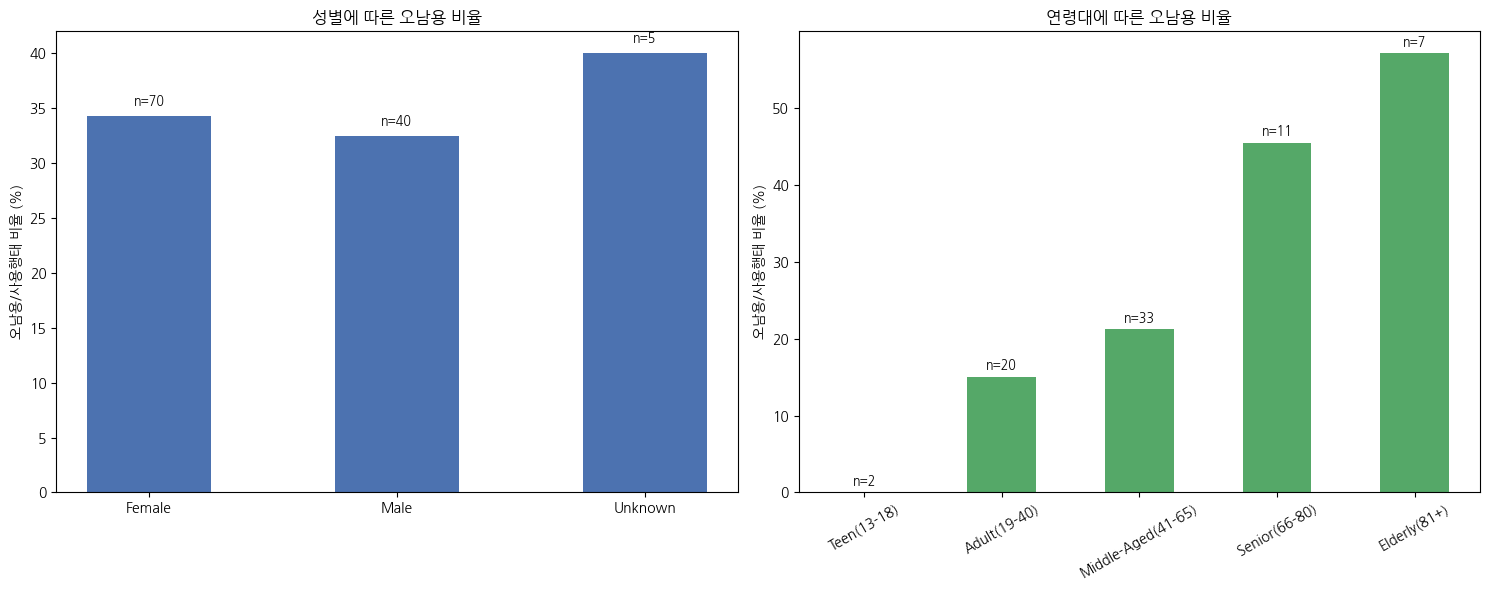

In [21]:
def classify_reaction(reaction):
    t = str(reaction).upper()
    if any(k in t for k in ['MISUSE','DEPENDENCE','OFF LABEL','OFF-LABEL','INCORRECT DOSE','INCORRECT PRODUCT',
                             'WRONG TECHNIQUE','UNAPPROVED','INAPPROPRIATE','EXPIRED PRODUCT','EXTRA DOSE',
                             'OVERDOSE','INTENTIONAL','SCREEN POSITIVE','AMPHETAMINE','PRODUCT LABEL',
                             'PRODUCT USE','PRODUCT PACKAGE','SELF MEDICATION','SELF-MEDICATION',
                             'INCORRECT DRUG ADMINISTRATION','INAPPROPRIATE AGE']):
        return '오남용/사용행태'
    return '기타'

C['is_misuse'] = C['primary_reaction'].apply(classify_reaction)  # 이 줄이 빠져있었어요

sex_tab = C.groupby('patient_sex')['is_misuse'].apply(lambda x: (x=='오남용/사용행태').mean()*100).round(1)
sex_n = C.groupby('patient_sex').size()

C_age = C[C['age_group'] != 'Unknown']
age_order = ['Teen(13-18)','Adult(19-40)','Middle-Aged(41-65)','Senior(66-80)','Elderly(81+)']
age_tab = C_age.groupby('age_group')['is_misuse'].apply(lambda x: (x=='오남용/사용행태').mean()*100).round(1)
age_tab = age_tab.reindex([a for a in age_order if a in age_tab.index])
age_n = C_age.groupby('age_group').size().reindex(age_tab.index)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bars1 = axes[0].bar(sex_tab.index, sex_tab.values, color='#4C72B0', width=0.5)
for bar, n in zip(bars1, sex_n.reindex(sex_tab.index).values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'n={n}', ha='center', fontsize=9)
axes[0].set_ylabel('오남용/사용행태 비율 (%)')
axes[0].set_title('성별에 따른 오남용 비율') #Chi-square p=1.0000, 유의하지 않음

bars2 = axes[1].bar(age_tab.index, age_tab.values, color='#55A868', width=0.5)
for bar, n in zip(bars2, age_n.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'n={n}', ha='center', fontsize=9)
axes[1].set_ylabel('오남용/사용행태 비율 (%)')
axes[1].set_title('연령대에 따른 오남용 비율') #Chi-square p=0.1325, 유의하지 않음
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [22]:
def classify_cardio(reaction):
    t = str(reaction).upper()
    if any(k in t for k in ['HYPERTENS','HYPOTENS','TACHYCARDIA','BRADYCARDIA','PALPITAT','ARRHYTHMIA',
                             'MYOCARDIAL','CARDIAC','CARDIOMYOPATHY','QT ','EXTRASYSTOLE','FLUSHING',
                             'VASOSPASM','ANGINA','INFARCTION']):
        return '심혈관계'
    return '기타'

C['is_cardio_cat'] = C['primary_reaction'].apply(classify_cardio)  # 이 줄 필요

tab_lt = pd.crosstab(C['is_life_threat'].astype(str), C['is_cardio_cat'])
chi2, p, dof, exp = chi2_contingency(tab_lt)
print(tab_lt)
print(f'chi2={chi2:.2f}, p={p:.4f}')

lt = C[C['is_life_threat'].astype(str) == 'True']
print(f"생명위협 케이스 {len(lt)}건 중 심혈관계가 주반응: {(lt['is_cardio_cat']=='심혈관계').sum()}건 ({(lt['is_cardio_cat']=='심혈관계').mean()*100:.1f}%)")

is_cardio_cat   기타  심혈관계
is_life_threat          
False           97     6
True             6     6
chi2=17.96, p=0.0000
생명위협 케이스 12건 중 심혈관계가 주반응: 6건 (50.0%)


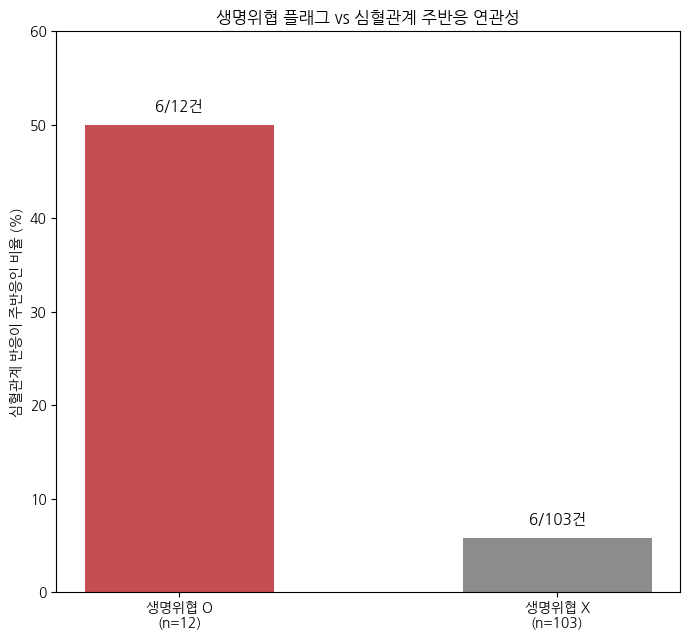

In [23]:
plt.rcParams['axes.unicode_minus'] = False

groups = ['생명위협 O\n(n=12)', '생명위협 X\n(n=103)']
cardio_pct = [
    (lt['is_cardio_cat']=='심혈관계').mean()*100,
    (C[C['is_life_threat'].astype(str)=='False']['is_cardio_cat']=='심혈관계').mean()*100
]
counts = [
    f"{(lt['is_cardio_cat']=='심혈관계').sum()}/{len(lt)}건",
    f"{(C[C['is_life_threat'].astype(str)=='False']['is_cardio_cat']=='심혈관계').sum()}/{(C['is_life_threat'].astype(str)=='False').sum()}건"
]

fig, ax = plt.subplots(figsize=(7, 6.5))
bars = ax.bar(groups, cardio_pct, color=['#C44E52', '#8C8C8C'], width=0.5)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, c, ha='center', fontsize=11)

ax.set_ylabel('심혈관계 반응이 주반응인 비율 (%)')
ax.set_title('생명위협 플래그 vs 심혈관계 주반응 연관성')#Chi-square p<0.0001
ax.set_ylim(0, 60)
plt.tight_layout()
plt.show()

성별: chi2=0.52, p=0.4700
연령대: chi2=10.27, p=0.0679 (n=74)


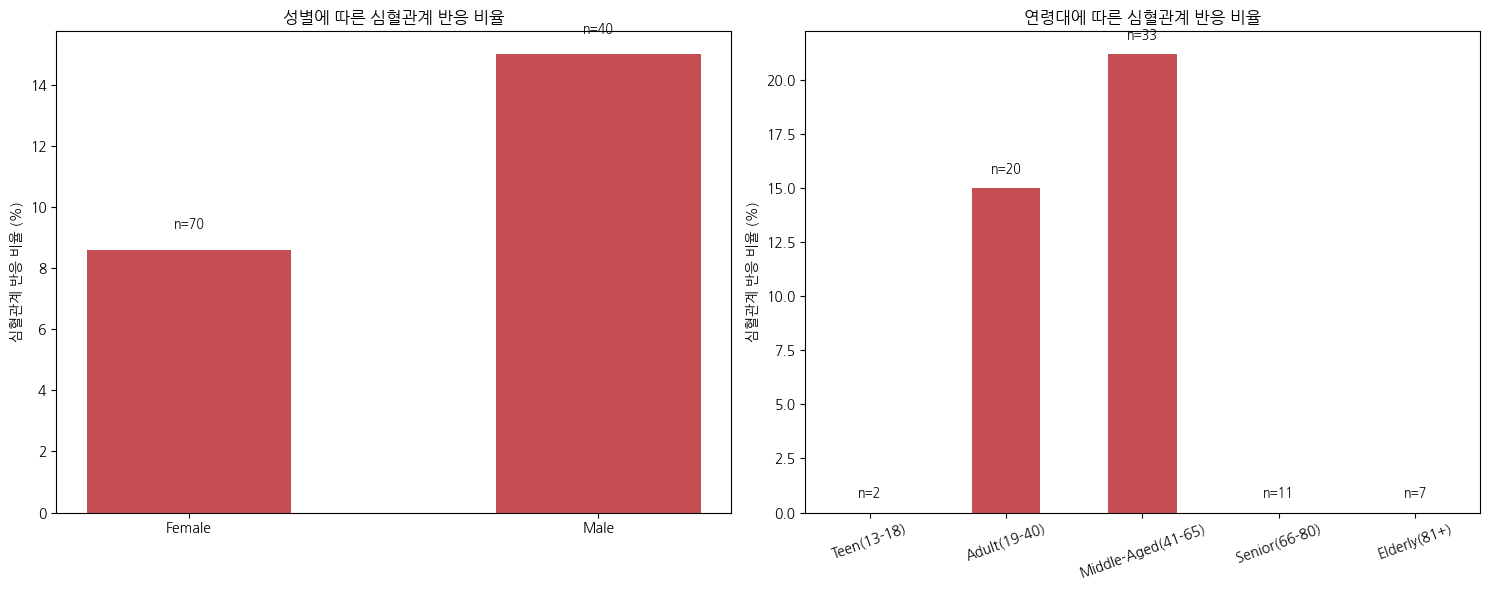

In [24]:
def classify_cardio(reaction):
    t = str(reaction).upper()
    if any(k in t for k in ['HYPERTENS','HYPOTENS','TACHYCARDIA','BRADYCARDIA','PALPITAT','ARRHYTHMIA',
                             'MYOCARDIAL','CARDIAC','CARDIOMYOPATHY','QT ','EXTRASYSTOLE','FLUSHING',
                             'VASOSPASM','ANGINA','INFARCTION']):
        return '심혈관계'
    return '기타'
C['is_cardio_cat'] = C['primary_reaction'].apply(classify_cardio)


# 성별
tab_sex = pd.crosstab(C['patient_sex'], C['is_cardio_cat']).loc[['Female','Male']]
chi2, p_sex, dof, exp = chi2_contingency(tab_sex)
print(f'성별: chi2={chi2:.2f}, p={p_sex:.4f}')

# 연령대
C_age = C[C['age_group'] != 'Unknown']
tab_age = pd.crosstab(C_age['age_group'], C_age['is_cardio_cat'])
chi2, p_age, dof, exp = chi2_contingency(tab_age)
print(f'연령대: chi2={chi2:.2f}, p={p_age:.4f} (n={len(C_age)})')

plt.rcParams['axes.unicode_minus'] = False

sex_pct = C.groupby('patient_sex')['is_cardio_cat'].apply(lambda x: (x=='심혈관계').mean()*100).round(1)
sex_n = C.groupby('patient_sex').size()

age_order = ['Teen(13-18)','Adult(19-40)','Middle-Aged(41-65)','Senior(66-80)','Elderly(81+)']
age_pct = C_age.groupby('age_group')['is_cardio_cat'].apply(lambda x: (x=='심혈관계').mean()*100).round(1)
age_pct = age_pct.reindex([a for a in age_order if a in age_pct.index])
age_n = C_age.groupby('age_group').size().reindex(age_pct.index)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bars1 = axes[0].bar(['Female','Male'], sex_pct.reindex(['Female','Male']).values, color='#C44E52', width=0.5)
for bar, n in zip(bars1, sex_n.reindex(['Female','Male']).values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.7, f'n={n}', ha='center', fontsize=9)
axes[0].set_ylabel('심혈관계 반응 비율 (%)')
axes[0].set_title(f'성별에 따른 심혈관계 반응 비율')

bars2 = axes[1].bar(age_pct.index, age_pct.values, color='#C44E52', width=0.5)
for bar, n in zip(bars2, age_n.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.7, f'n={n}', ha='center', fontsize=9)
axes[1].set_ylabel('심혈관계 반응 비율 (%)')
axes[1].set_title(f'연령대에 따른 심혈관계 반응 비율')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [25]:
def ingredient(row):
    t = (str(row['suspect_drug']).upper() + ' ' + str(row['brand_name']).upper())
    if 'PSEUDOEPHEDRINE' in t or 'SUDAFED' in t: return 'Pseudoephedrine'
    if 'PHENYLEPHRINE' in t or 'NEO-SYNEPHRINE' in t: return 'Phenylephrine'
    if 'OXYMETAZOLINE' in t or 'AFRIN' in t: return 'Oxymetazoline'
    return 'Other'
C['ingredient'] = C.apply(ingredient, axis=1)

C_age = C[C['age_group'] != 'Unknown'].copy()
C_age['is_senior_plus'] = C_age['age_group'].isin(['Senior(66-80)','Elderly(81+)'])

tab = pd.crosstab(C_age['is_senior_plus'], C_age['ingredient'] == 'Oxymetazoline')
chi2, p, dof, exp = chi2_contingency(tab)
print(tab)
print(f'65세 이상 여부 x Oxymetazoline 사용: chi2={chi2:.2f}, p={p:.4f}')

pct_oxy = C_age.groupby('is_senior_plus').apply(lambda d: (d['ingredient']=='Oxymetazoline').mean()*100)
print(f'\n65세 미만 Oxymetazoline 비중: {pct_oxy[False]:.1f}%')
print(f'65세 이상 Oxymetazoline 비중: {pct_oxy[True]:.1f}%')

phen_by_age = C_age.groupby('age_group').apply(lambda d: (d['ingredient']=='Phenylephrine').sum())
print('\n연령대별 Phenylephrine 사용 건수:')

ingredient      False  True 
is_senior_plus              
False              54      2
True               14      4
65세 이상 여부 x Oxymetazoline 사용: chi2=4.10, p=0.0428

65세 미만 Oxymetazoline 비중: 3.6%
65세 이상 Oxymetazoline 비중: 22.2%

연령대별 Phenylephrine 사용 건수:


/tmp/ipykernel_3740/2719161405.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_oxy = C_age.groupby('is_senior_plus').apply(lambda d: (d['ingredient']=='Oxymetazoline').mean()*100)
/tmp/ipykernel_3740/2719161405.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  phen_by_age = C_age.groupby('age_group').apply(lambda d: (d['ingredient']=='Phenylephrine').sum())


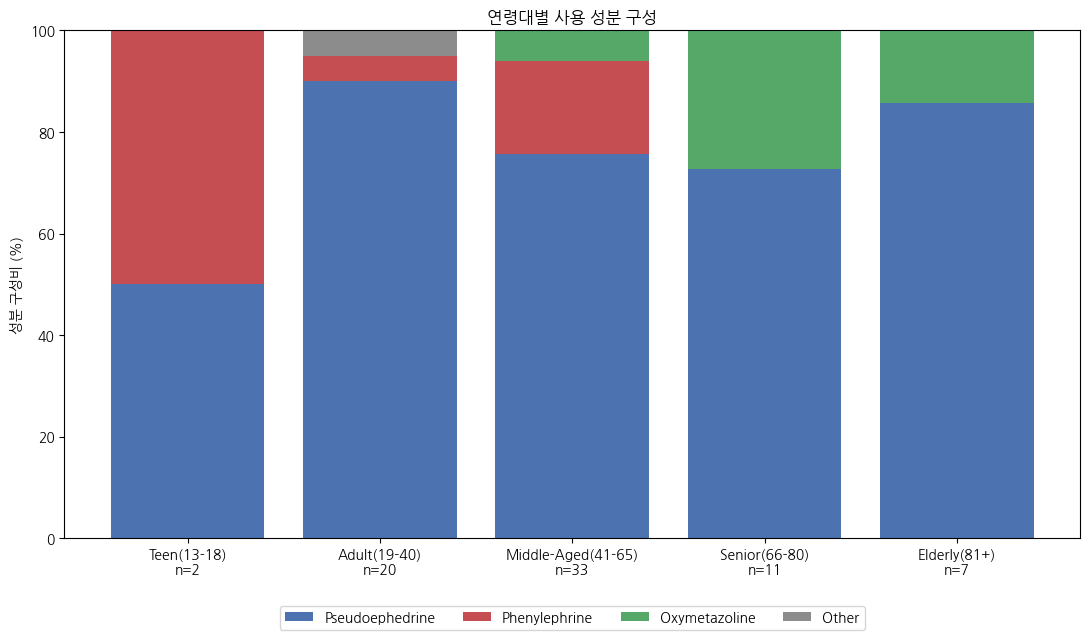

In [26]:
plt.rcParams['axes.unicode_minus'] = False

age_order = ['Teen(13-18)','Adult(19-40)','Middle-Aged(41-65)','Senior(66-80)','Elderly(81+)']

tab = pd.crosstab(C_age['age_group'], C_age['ingredient'])
tab = tab.reindex(age_order)
totals = tab.sum(axis=1)
tab_pct = tab.div(totals, axis=0) * 100

labels = [f'{age}\nn={int(n)}' for age, n in zip(tab_pct.index, totals)]
colors = {'Pseudoephedrine':'#4C72B0', 'Phenylephrine':'#C44E52', 'Oxymetazoline':'#55A868', 'Other':'#8C8C8C'}

fig, ax = plt.subplots(figsize=(11, 6.5))
bottom = pd.Series(0, index=tab_pct.index)
for col in ['Pseudoephedrine','Phenylephrine','Oxymetazoline','Other']:
    if col in tab_pct.columns:
        ax.bar(labels, tab_pct[col], bottom=bottom, label=col, color=colors[col])
        bottom = bottom + tab_pct[col]

ax.set_ylabel('성분 구성비 (%)')
ax.set_title('연령대별 사용 성분 구성')
# 65세 이상: Phenylephrine 0건, Oxymetazoline 비중 유의하게 높음 p=0.0428
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4)
plt.tight_layout()
plt.show()